In [9]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr

# Dataseti yükləyirik
df = sns.load_dataset("penguins").dropna() # Boş xanaları silirik ki, hesablamada xəta olmasın

# İlk 5 sətirə baxış
print(df.head())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
4  Adelie  Torgersen            36.7           19.3              193.0   
5  Adelie  Torgersen            39.3           20.6              190.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
4       3450.0  Female  
5       3650.0    Male  


Task 1: Compute Pearson and Spearman Correlations

In [10]:
#Select all numeric feature pairs in the dataset.
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols

Index(['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'], dtype='object')

In [11]:
#Compute the Pearson and Spearman correlation matrix using pandas or scipy.
results = []
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        col1 = numeric_cols[i]
        col2 = numeric_cols[j]


        # p_r → correlation coefficient - amount of relationship [-1;1]
        # p_pval → p-value - is there really a relationship? 
        # if p>0.05 relationship is not important, p<0.05 it is important
        p_r, p_val = pearsonr(df[col1], df[col2])

        #s_rho - correlation amount [-1;1]
        #s_pval - p value - is there really a relationship?
        #if p_val < 0.05 important, p_val > 0.05 not important
        s_rho, s_pval = spearmanr(df[col1], df[col2])
        

        results.append({
            'Pair' : f'{col1} & {col2}',
            'Pearson r' : round(p_r, 4),
            'Pearson p-val' : f'{p_val:.2e}',
            'Spearman p' : round(s_rho, 4),
            'Spearman p-val' : f'{s_pval:.2e}',
            'Difference (abs)' : round(abs(p_r-s_rho),4)
        })


corr_summary = pd.DataFrame(results)
print(corr_summary.sort_values(by='Difference (abs)', ascending=False))
corr_summary

                                     Pair  Pearson r Pearson p-val  \
6       bill_depth_mm & flipper_length_mm    -0.5778      4.78e-31   
9       flipper_length_mm & bill_depth_mm    -0.5778      4.78e-31   
13            body_mass_g & bill_depth_mm    -0.4720      7.02e-20   
7             bill_depth_mm & body_mass_g    -0.4720      7.02e-20   
11        flipper_length_mm & body_mass_g     0.8730     3.13e-105   
14        body_mass_g & flipper_length_mm     0.8730     3.13e-105   
2      bill_length_mm & flipper_length_mm     0.6531      7.21e-42   
8      flipper_length_mm & bill_length_mm     0.6531      7.21e-42   
1          bill_length_mm & bill_depth_mm    -0.2286      2.53e-05   
4          bill_depth_mm & bill_length_mm    -0.2286      2.53e-05   
3            bill_length_mm & body_mass_g     0.5895      1.54e-32   
12           body_mass_g & bill_length_mm     0.5895      1.54e-32   
5           bill_depth_mm & bill_depth_mm     1.0000      0.00e+00   
0         bill_lengt

,Pair,Pearson r,Pearson p-val,Spearman p,Spearman p-val,Difference (abs)
0,bill_length_mm & bill_length_mm,1.0000,0.00e+00,1.0000,0.00e+00,0.0000
1,bill_length_mm & bill_depth_mm,-0.2286,2.53e-05,-0.2139,8.37e-05,0.0148
2,bill_length_mm & flipper_length_mm,0.6531,7.21e-42,0.6698,1.07e-44,0.0167
3,bill_length_mm & body_mass_g,0.5895,1.54e-32,0.5765,6.97e-31,0.0130
4,bill_depth_mm & bill_length_mm,-0.2286,2.53e-05,-0.2139,8.37e-05,0.0148
5,bill_depth_mm & bill_depth_mm,1.0000,0.00e+00,1.0000,0.00e+00,0.0000
6,bill_depth_mm & flipper_length_mm,-0.5778,4.78e-31,-0.5173,3.46e-24,0.0605
7,bill_depth_mm & body_mass_g,-0.4720,7.02e-20,-0.4293,2.31e-16,0.0427
8,flipper_length_mm & bill_length_mm,0.6531,7.21e-42,0.6698,1.07e-44,0.0167
9,flipper_length_mm & bill_depth_mm,-0.5778,4.78e-31,-0.5173,3.46e-24,0.0605


Which pairs show the strongest linear relationships?
The strongest linear relationship is found between flipper_length_mm and body_mas_g which is 0.87. This suggests a very high positive correlation. As a penguins body mass increases, its flipper length tends to increase in a nearly proportional linear fashion. This is expected in biological growth patterns 


Are there any pairs where Pearson and Spearman disagree noticeably? What might cause that?

We see minor discrepancies in several pairs, but the gap between r and ρ usually points to three main factors:

Outliers: Pearson's r is highly sensitive to extreme values. A single outlier can pull the "best fit line" toward it, whereas Spearman's ρ is based on ranks, making it much more robust against outliers.

Non-linear Monotonicity: If the relationship is "curved" (e.g., as X increases,Y increases but at an accelerating rate), Spearman will often be higher than Pearson. Spearman only cares that the order is preserved, not that the change is constant.

Simpson’s Paradox (The Hidden Lie): In pairs like bill_length_mm and bill_depth_mm, the correlation might appear weak or even negative. However, this "disagreement" with intuition is often caused by the fact that the data is an aggregate of three different species. When looked at as a whole, the distinct clusters of species can mask the true relationship within each group.

Task 2: Build a Correlation Heatmap

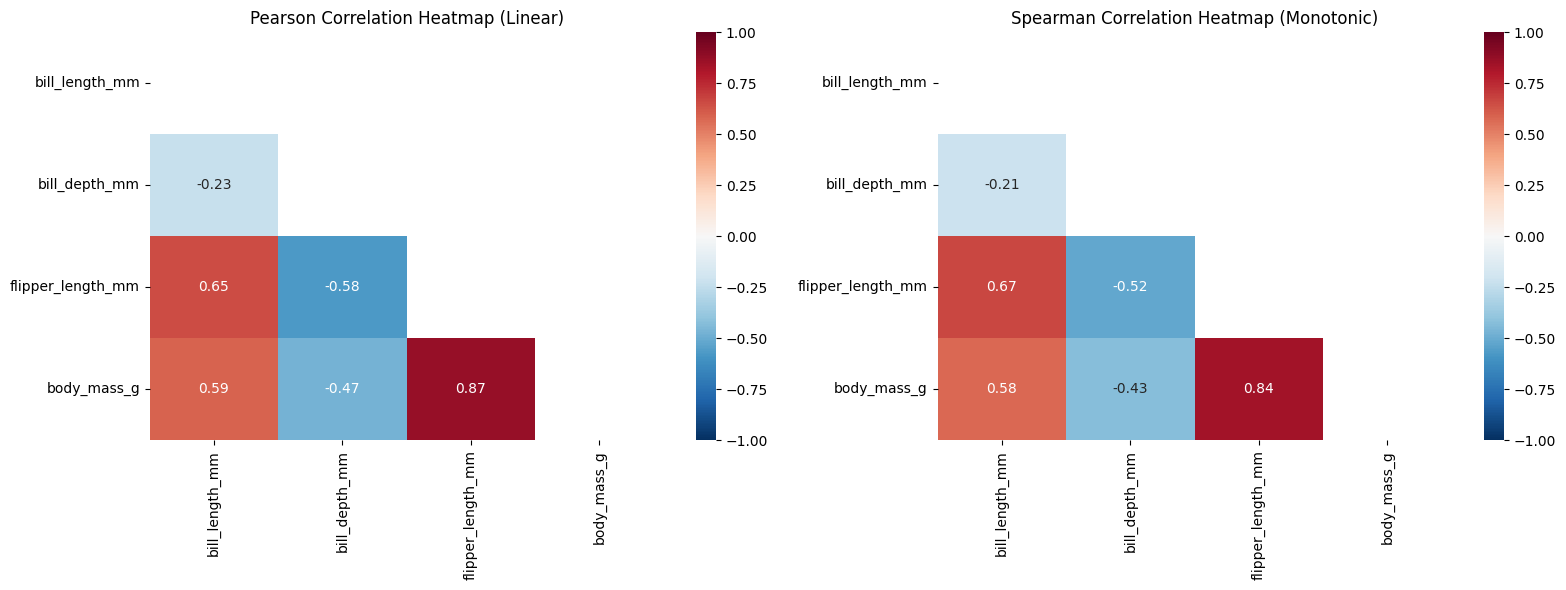

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Compute matrices 

pearson_corr = df.corr(method='pearson', numeric_only=True)
spearman_corr = df.corr(method='spearman', numeric_only=True)
#1 setir 2 sutundan ibaret qrafik sahesi ax1-sol ax2 sag plot. 16.6 qrafikin olculeri
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))

mask = np.triu(np.ones_like(pearson_corr, dtype=bool))

sns.heatmap(pearson_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, vmin=-1, vmax=1, ax=ax1)

ax1.set_title('Pearson Correlation Heatmap (Linear)')

# Heatmap 2: Spearman
sns.heatmap(spearman_corr, mask=mask, annot=True, fmt=".2f", cmap='RdBu_r', 
            center=0, vmin=-1, vmax=1, ax=ax2)
ax2.set_title('Spearman Correlation Heatmap (Monotonic)')
plt.tight_layout()
plt.show()


#annot=True rəqəmləri qrafikin içində göstərir
#fmt=".2f"  2 rəqəm onluq (0.85 kimi
#cmap='RdBu_r' rəng xəritəsi:  qırmızı → pozitiv  mavi → neqativ
#center=0  0 nöqtəsini ortada saxlayır
#vmin=-1, vmax=1 rəng aralığı sabit:
#-1 → tam mənfi

#+1 → tam pozitiv

#ax=ax1 bu qrafiki soldakı plot-a çək



1. Where do they agree?The heatmaps show strong agreement on the relationship between flipper_length_mm and body_mass_g. Both matrices display a high positive correlation (r = 0.87 and ρ 0.84).Insight: Because both values are high and similar, we can conclude that this relationship is robustly linear. The change in body mass consistently and proportionally tracks the change in flipper length.


2. Where do they differ, and what does it tell us?

The most notable differences appear when comparing bill_depth_mm with other features like body_mass_g or flipper_length_mm.

The Shape of Relationships: If Spearman (ρ) is higher than Pearson (r), it suggests a non-linear but monotonic relationship. This means the variables move in the same direction, but not at a constant rate. In biological data, this is common as some parts of an animal may grow at a different pace than others (allometry).

The Presence of Outliers: If Pearson is significantly lower than Spearman, it often indicates that outliers are present in the data. Pearson tries to minimize the squared distance to all points, so a few "weird" data points (like a very light penguin with a very deep bill) will pull the Pearson value toward zero more than they will affect the Spearman rank.

The "Zero" Zones: In both heatmaps, the correlations involving bill_depth_mm and bill_length_mm are quite low (near -0.2). This visual "cool" spot in the heatmap is actually a red flag for Simpson's Paradox. The heatmap tells us there is no relationship, but a scatter plot colored by species would reveal three very strong positive relationships hiding behind that single "aggregate" number.


Task 3: Scatterplot analysis of key pairs

three feature pairs with the highest absolute Pearson correlation 
Flipper Length vs. Body Mass

Bill Length vs. Flipper Length

Bill Length vs. Body Mass

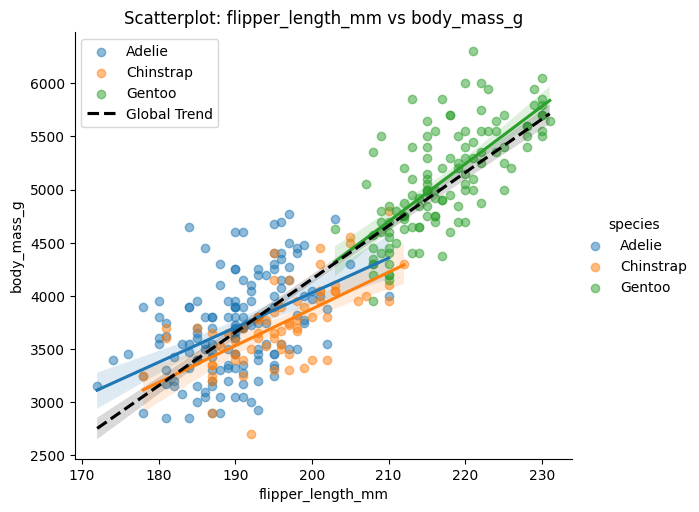

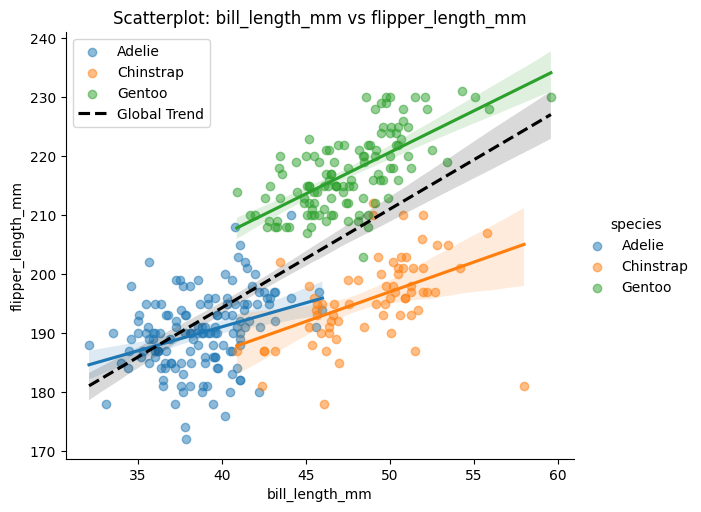

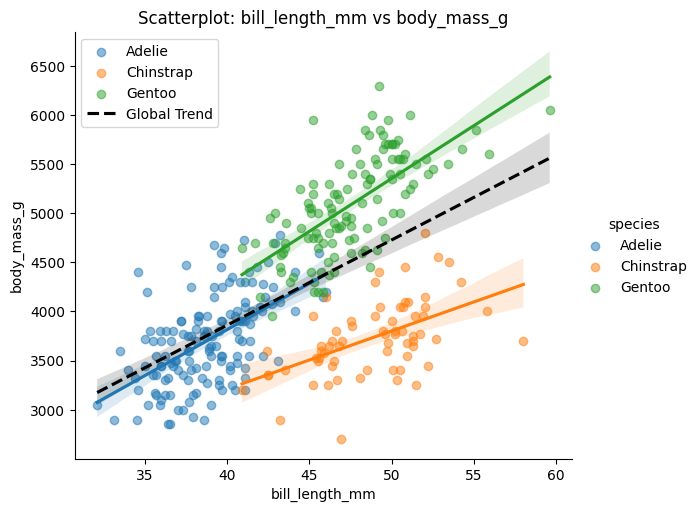

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Identifying the top 3 pairs based on absolute Pearson r from Task 1
# 1. flipper_length_mm & body_mass_g
# 2. bill_length_mm & flipper_length_mm
# 3. bill_length_mm & body_mass_g

top_pairs = [
    ("flipper_length_mm", "body_mass_g"),
    ("bill_length_mm", "flipper_length_mm"),
    ("bill_length_mm", "body_mass_g")
]
for x_col, y_col in top_pairs:
    # We use lmplot to show the global trend while coloring by species
    g = sns.lmplot(data=df, x=x_col, y=y_col, hue="species", 
                   height=5, aspect=1.2, scatter_kws={'alpha':0.5})
    
    # Adding a global regression line in a different color to compare
    sns.regplot(data=df, x=x_col, y=y_col, scatter=False, ax=g.ax, 
                color='black', label='Global Trend', line_kws={'linestyle':'--'})
    
    plt.title(f"Scatterplot: {x_col} vs {y_col}")
    plt.legend()
    plt.show()

Does the regression line capture the actual pattern well?
Flipper Length vs. Body Mass: The global regression line (black dashed line) captures this relationship quite well. All species follow a similar upward trajectory, meaning a single correlation number is fairly "honest" here.

Bill Length vs. Flipper/Body Mass: The global line is "okay," but it starts to struggle. You can see the data points form distinct "islands" (clusters). While the general trend is upward, the global line doesn't perfectly represent any single species—it's an average of three different biological groups.

2. Do subgroups show different slopes or intercepts?
This is where the nuance of the dataset becomes visible:

Slopes: For Flipper Length vs. Body Mass, the slopes for Adelie, Chinstrap, and Gentoo are remarkably similar. This means the "rate of growth" is consistent across species.

Intercepts (Offsets): The intercepts differ significantly. For the same flipper length, a Gentoo penguin is generally much heavier than an Adelie or Chinstrap.

The Diagnostic Lesson: If we ignore the species (the categorical grouping), we might assume one rule fits all. However, the scatterplots show that while the direction of the relationship is consistent, the starting point (intercept) depends heavily on the species.

Key Finding: A high Pearson correlation (r>0.8) usually means the global regression line looks good, but the scatterplot reveals that the "strength" of that relationship can vary when you look at individual subgroups.